In [3]:
import pandas as pd
df = pd.read_csv("../data/training_features.csv")

In [4]:
df.head(10)

,date,home_team,away_team,tournament,neutral,result,home_ranking,away_ranking,ranking_diff,home_elo,...,away_form_gf,away_form_ga,away_form_gd,h2h_matches,h2h_home_wins,h2h_away_wins,h2h_draws,home_days_rest,away_days_rest,is_world_cup
0,2026-06-18,Mexico,South Korea,FIFA World Cup,0,HOME,15.0,25.0,10.0,1860.0,...,8,6,2,10,5,2,3,7,7,1
1,2026-06-18,Switzerland,Bosnia and Herzegovina,FIFA World Cup,1,HOME,19.0,52.0,33.0,1889.0,...,4,4,0,1,0,1,0,5,6,1
2,2026-06-18,Czech Republic,South Africa,FIFA World Cup,1,DRAW,41.0,60.0,19.0,1726.0,...,3,5,-2,1,0,0,1,7,7,1
3,2026-06-18,Canada,Qatar,FIFA World Cup,0,HOME,30.0,35.0,5.0,1784.0,...,2,6,-4,1,1,0,0,6,5,1
4,2026-06-17,England,Croatia,FIFA World Cup,1,HOME,4.0,11.0,7.0,2020.0,...,8,9,-1,10,6,3,1,7,10,1
5,2026-06-17,Ghana,Panama,FIFA World Cup,1,HOME,65.0,53.0,-12.0,1503.0,...,10,11,-1,0,0,0,0,15,11,1
6,2026-06-17,Portugal,Congo DR,FIFA World Cup,1,DRAW,5.0,51.0,46.0,1984.0,...,4,3,1,0,0,0,0,7,8,1
7,2026-06-17,Uzbekistan,Colombia,FIFA World Cup,1,AWAY,62.0,13.0,-49.0,1727.0,...,10,6,4,0,0,0,0,9,10,1
8,2026-06-16,Argentina,Algeria,FIFA World Cup,1,HOME,3.0,36.0,33.0,2113.0,...,12,2,10,1,1,0,0,7,6,1
9,2026-06-16,Austria,Jordan,FIFA World Cup,1,HOME,23.0,68.0,45.0,1827.0,...,7,13,-6,0,0,0,0,15,9,1


In [5]:
df.describe()

,neutral,home_ranking,away_ranking,ranking_diff,home_elo,away_elo,elo_diff,home_squad_age,away_squad_age,home_market_value,...,away_form_gf,away_form_ga,away_form_gd,h2h_matches,h2h_home_wins,h2h_away_wins,h2h_draws,home_days_rest,away_days_rest,is_world_cup
count,15844.000000,5034.000000,4371.000000,12045.00000,5034.000000,4371.000000,12045.000000,7006.000000,6401.000000,6.793000e+03,...,15844.000000,15844.000000,15844.000000,15844.000000,15844.000000,15844.000000,15844.000000,15844.000000,15844.000000,15844.000000
mean,0.305478,30.516289,33.824983,3.78489,1791.226063,1785.017616,12.931756,27.199994,27.210073,2.834373e+08,...,6.661007,6.880964,-0.219957,5.645481,2.246718,1.998864,1.399899,36.571699,37.877177,0.239397
std,0.460624,22.524434,23.636749,38.47230,175.228712,171.285508,180.828449,1.110358,1.166970,3.202573e+08,...,3.945266,4.584053,6.879172,3.889560,2.296005,2.164100,1.536697,47.291967,49.423965,0.426729
min,0.000000,1.000000,1.000000,-99.00000,1425.000000,1425.000000,-688.000000,24.600000,24.600000,5.300000e+06,...,0.000000,0.000000,-73.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,14.000000,0.00000,1689.000000,1676.000000,0.000000,26.400000,26.600000,4.445000e+07,...,4.000000,4.000000,-4.000000,2.000000,0.000000,0.000000,0.000000,4.000000,4.000000,0.000000
50%,0.000000,25.000000,30.000000,0.00000,1783.000000,1767.000000,0.000000,27.100000,27.200000,1.616400e+08,...,6.000000,6.000000,0.000000,6.000000,2.000000,1.000000,1.000000,8.000000,8.000000,0.000000
75%,1.000000,47.000000,53.000000,6.00000,1912.000000,1904.000000,18.000000,27.900000,28.000000,3.708000e+08,...,9.000000,9.000000,4.000000,10.000000,4.000000,3.000000,2.000000,61.000000,62.000000,0.000000
max,1.000000,95.000000,95.000000,99.00000,2165.000000,2165.000000,677.000000,29.300000,29.300000,1.300000e+09,...,34.000000,74.000000,31.000000,10.000000,10.000000,10.000000,8.000000,180.000000,180.000000,1.000000


## Exploratory Data Analysis

Goal: understand the available variables, their quality (missing values), their relationship with the target variable `result`, and their correlations with each other, in order to select the most relevant features for the model.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15844 entries, 0 to 15843
Data columns (total 34 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                15844 non-null  object 
 1   home_team           15844 non-null  object 
 2   away_team           15844 non-null  object 
 3   tournament          15844 non-null  object 
 4   neutral             15844 non-null  int64  
 5   result              15844 non-null  object 
 6   home_ranking        5034 non-null   float64
 7   away_ranking        4371 non-null   float64
 8   ranking_diff        12045 non-null  float64
 9   home_elo            5034 non-null   float64
 10  away_elo            4371 non-null   float64
 11  elo_diff            12045 non-null  float64
 12  home_squad_age      7006 non-null   float64
 13  away_squad_age      6401 non-null   float64
 14  home_market_value   6793 non-null   float64
 15  away_market_value   6256 non-null   float64
 16  mark

### Missing Values

Many features (ranking, elo, market value, squad age) come from external sources that do not cover all matches/periods. The NaN rate per column directly determines their usability: a feature with 70% NaN will need careful imputation or should be excluded.

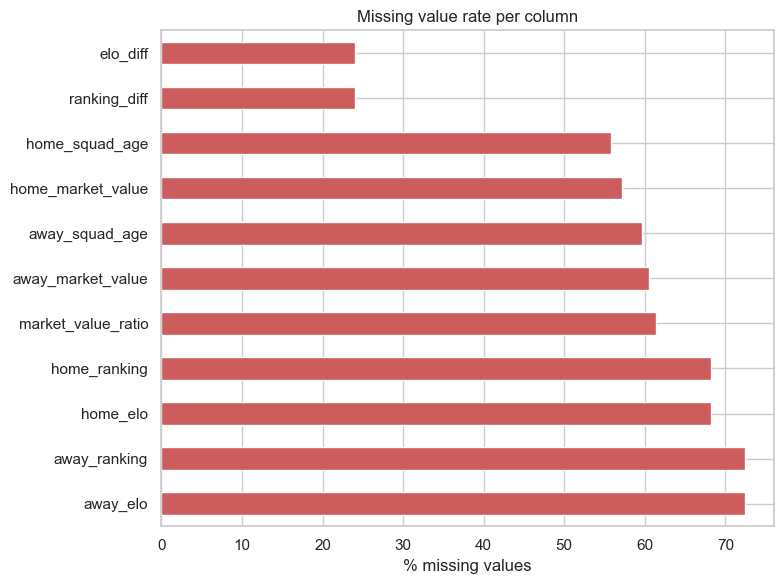

away_elo              72.412270
away_ranking          72.412270
home_elo              68.227720
home_ranking          68.227720
market_value_ratio    61.360767
away_market_value     60.515021
away_squad_age        59.599849
home_market_value     57.125726
home_squad_age        55.781368
ranking_diff          23.977531
elo_diff              23.977531
dtype: float64

In [7]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 6))
missing.plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel("% missing values")
ax.set_title("Missing value rate per column")
plt.tight_layout()
plt.show()

missing

### Target Variable Distribution

`result` is the target (HOME / DRAW / AWAY). Its distribution gives the baseline to beat (majority class) and indicates whether rebalancing (class_weight, SMOTE...) will be needed.

result
HOME    47.847766
AWAY    28.932088
DRAW    23.220146
Name: proportion, dtype: float64


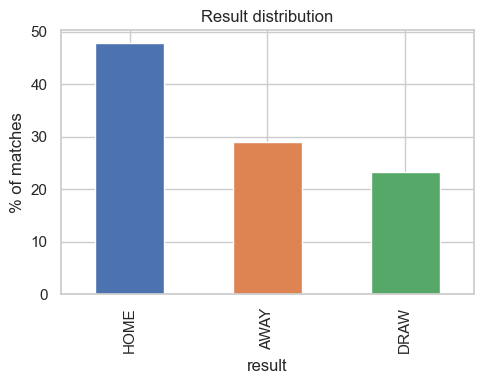

In [8]:
result_counts = df["result"].value_counts(normalize=True) * 100
print(result_counts)

fig, ax = plt.subplots(figsize=(5, 4))
result_counts.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452", "#55a868"])
ax.set_ylabel("% of matches")
ax.set_title("Result distribution")
plt.tight_layout()
plt.show()

### Correlation Matrix of Numerical Features

Helps identify:
- features strongly correlated with each other (redundancy / multicollinearity, e.g. `home_ranking` vs `home_elo`, or `home_form_gd` vs `home_form_win_rate`) → one can often be removed;
- features most correlated with the encoded result → good candidates to keep first.

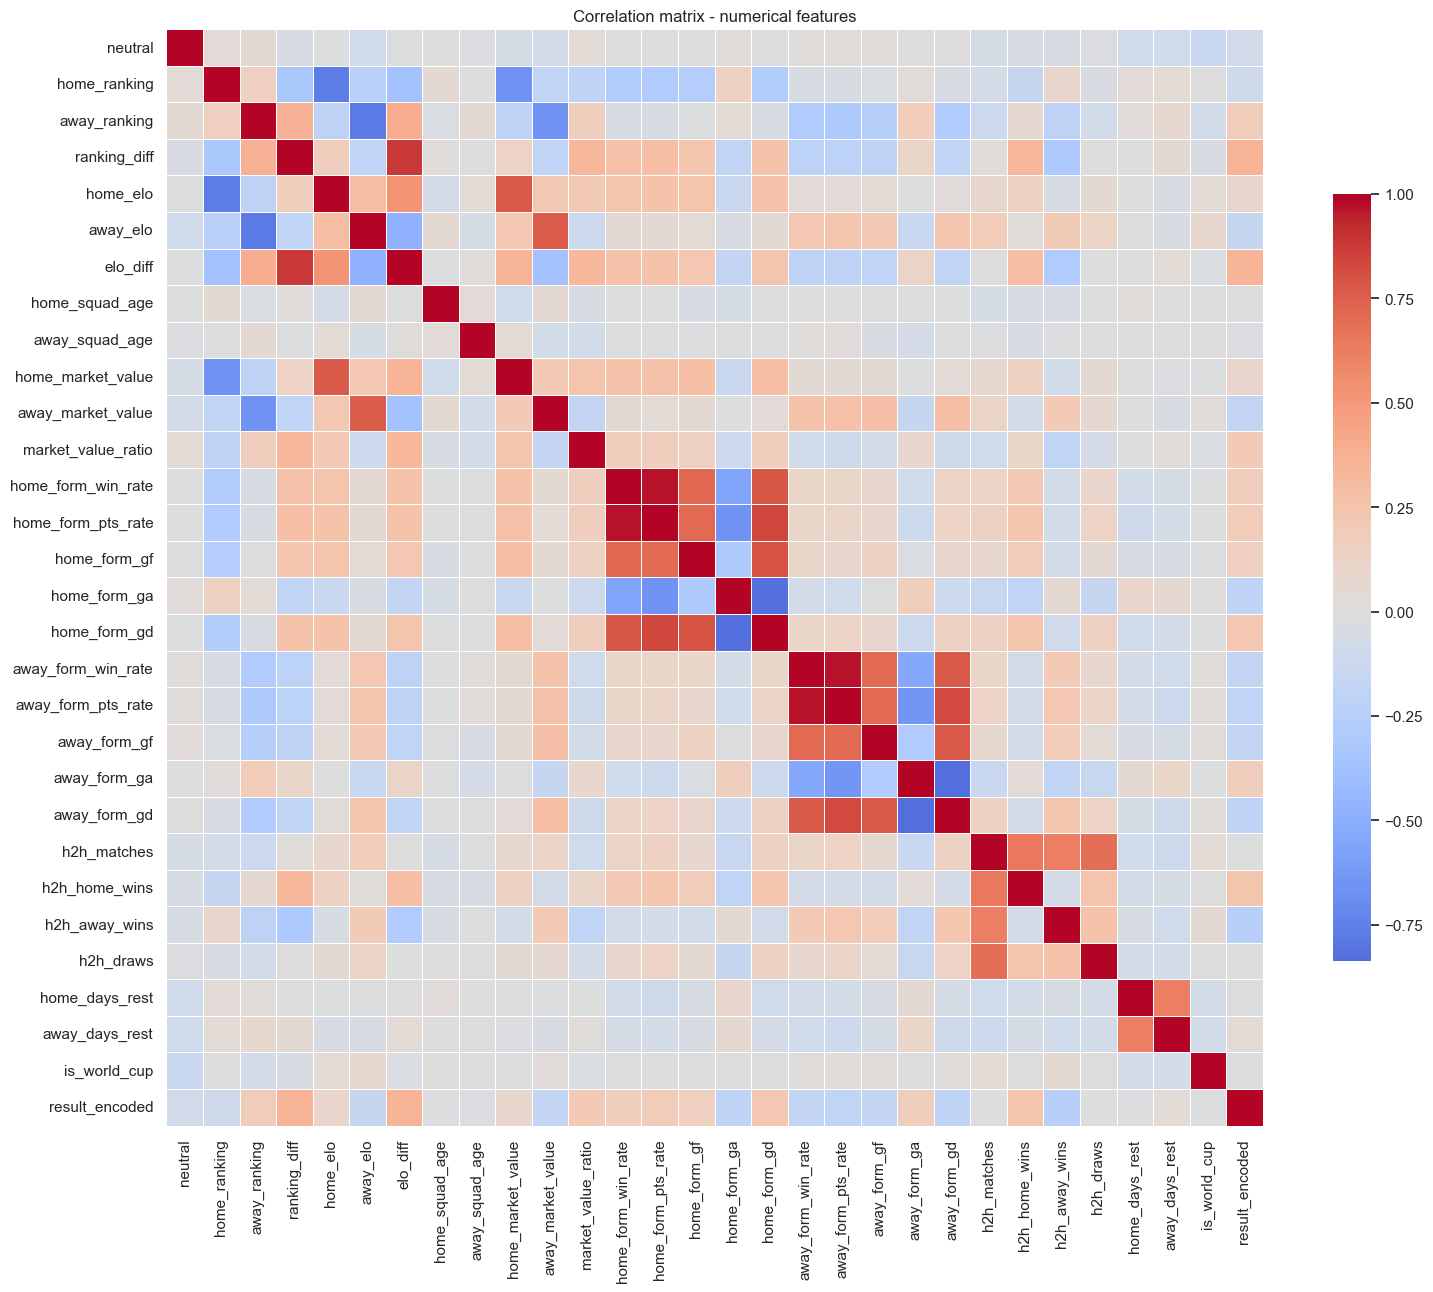

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# numeric encoding of the target to include it in the correlation matrix
result_map = {"AWAY": -1, "DRAW": 0, "HOME": 1}
df["result_encoded"] = df["result"].map(result_map)

corr_cols = numeric_cols + ["result_encoded"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7},
    ax=ax,
)
ax.set_title("Correlation matrix - numerical features")
plt.tight_layout()
plt.show()

### Correlation of Each Feature with the Result

Features ranked by absolute correlation with `result_encoded`: a quick first filter to prioritise variables to test in the model.

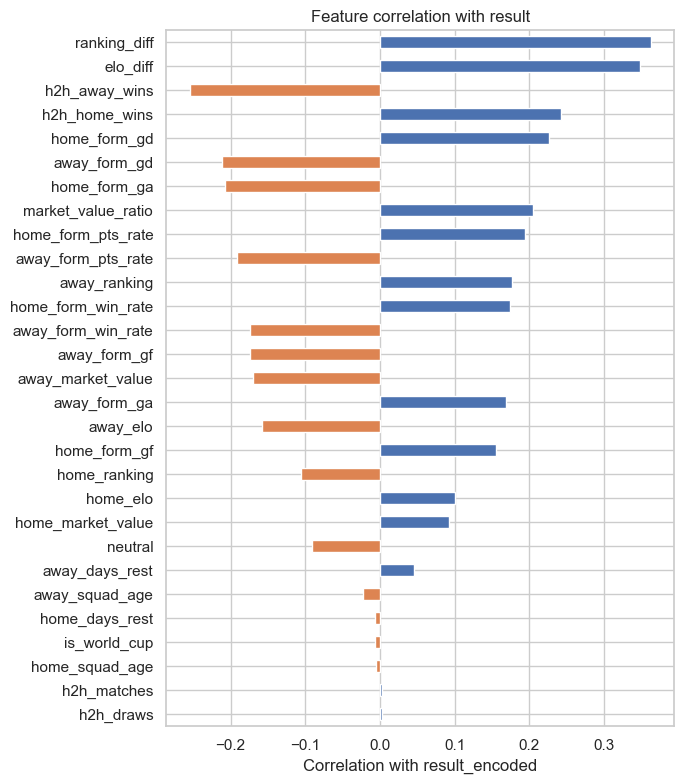

ranking_diff          0.362873
elo_diff              0.348611
h2h_away_wins        -0.254970
h2h_home_wins         0.242892
home_form_gd          0.226278
away_form_gd         -0.211934
home_form_ga         -0.207443
market_value_ratio    0.204636
home_form_pts_rate    0.194606
away_form_pts_rate   -0.191838
away_ranking          0.177443
home_form_win_rate    0.173943
away_form_win_rate   -0.173916
away_form_gf         -0.173581
away_market_value    -0.169533
away_form_ga          0.168651
away_elo             -0.158068
home_form_gf          0.155951
home_ranking         -0.105787
home_elo              0.100092
home_market_value     0.092200
neutral              -0.090411
away_days_rest        0.045107
away_squad_age       -0.022638
home_days_rest       -0.006317
is_world_cup         -0.006305
home_squad_age       -0.005432
h2h_matches           0.002456
h2h_draws             0.002376
Name: result_encoded, dtype: float64

In [10]:
target_corr = (
    corr["result_encoded"]
    .drop("result_encoded")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 8))
target_corr.plot(kind="barh", ax=ax, color=np.where(target_corr > 0, "#4c72b0", "#dd8452"))
ax.invert_yaxis()
ax.set_xlabel("Correlation with result_encoded")
ax.set_title("Feature correlation with result")
plt.tight_layout()
plt.show()

target_corr

### Highly Correlated Feature Pairs (Multicollinearity)

If two features are highly correlated (|corr| > 0.8), they carry redundant information: one can often be dropped to simplify the model and reduce coefficient instability (especially in logistic regression).

In [11]:
feature_corr = corr.drop("result_encoded").drop(columns="result_encoded")
pairs = (
    feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
    .stack()
    .rename("corr")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
strong_pairs = pairs[pairs["corr"].abs() > 0.8].sort_values("corr", key=lambda s: s.abs(), ascending=False)
strong_pairs

,feature_1,feature_2,corr
270,home_form_win_rate,home_form_pts_rate,0.967284
340,away_form_win_rate,away_form_pts_rate,0.964901
83,ranking_diff,elo_diff,0.879089
288,home_form_pts_rate,home_form_gd,0.841774
370,away_form_ga,away_form_gd,-0.836726
353,away_form_pts_rate,away_form_gd,0.832334
315,home_form_ga,home_form_gd,-0.825490


### Distribution of Key Features by Result

Boxplots of differences (ranking, elo, market value, form) by match outcome: the clearer the separation between HOME / DRAW / AWAY, the more discriminative the feature is for the model.

C:\Users\Amélie\AppData\Local\Temp\ipykernel_19472\1849835594.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="result", y=col, order=order, ax=ax, palette="Set2", showfliers=False)
C:\Users\Amélie\AppData\Local\Temp\ipykernel_19472\1849835594.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="result", y=col, order=order, ax=ax, palette="Set2", showfliers=False)
C:\Users\Amélie\AppData\Local\Temp\ipykernel_19472\1849835594.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="result", y=col, order=orde

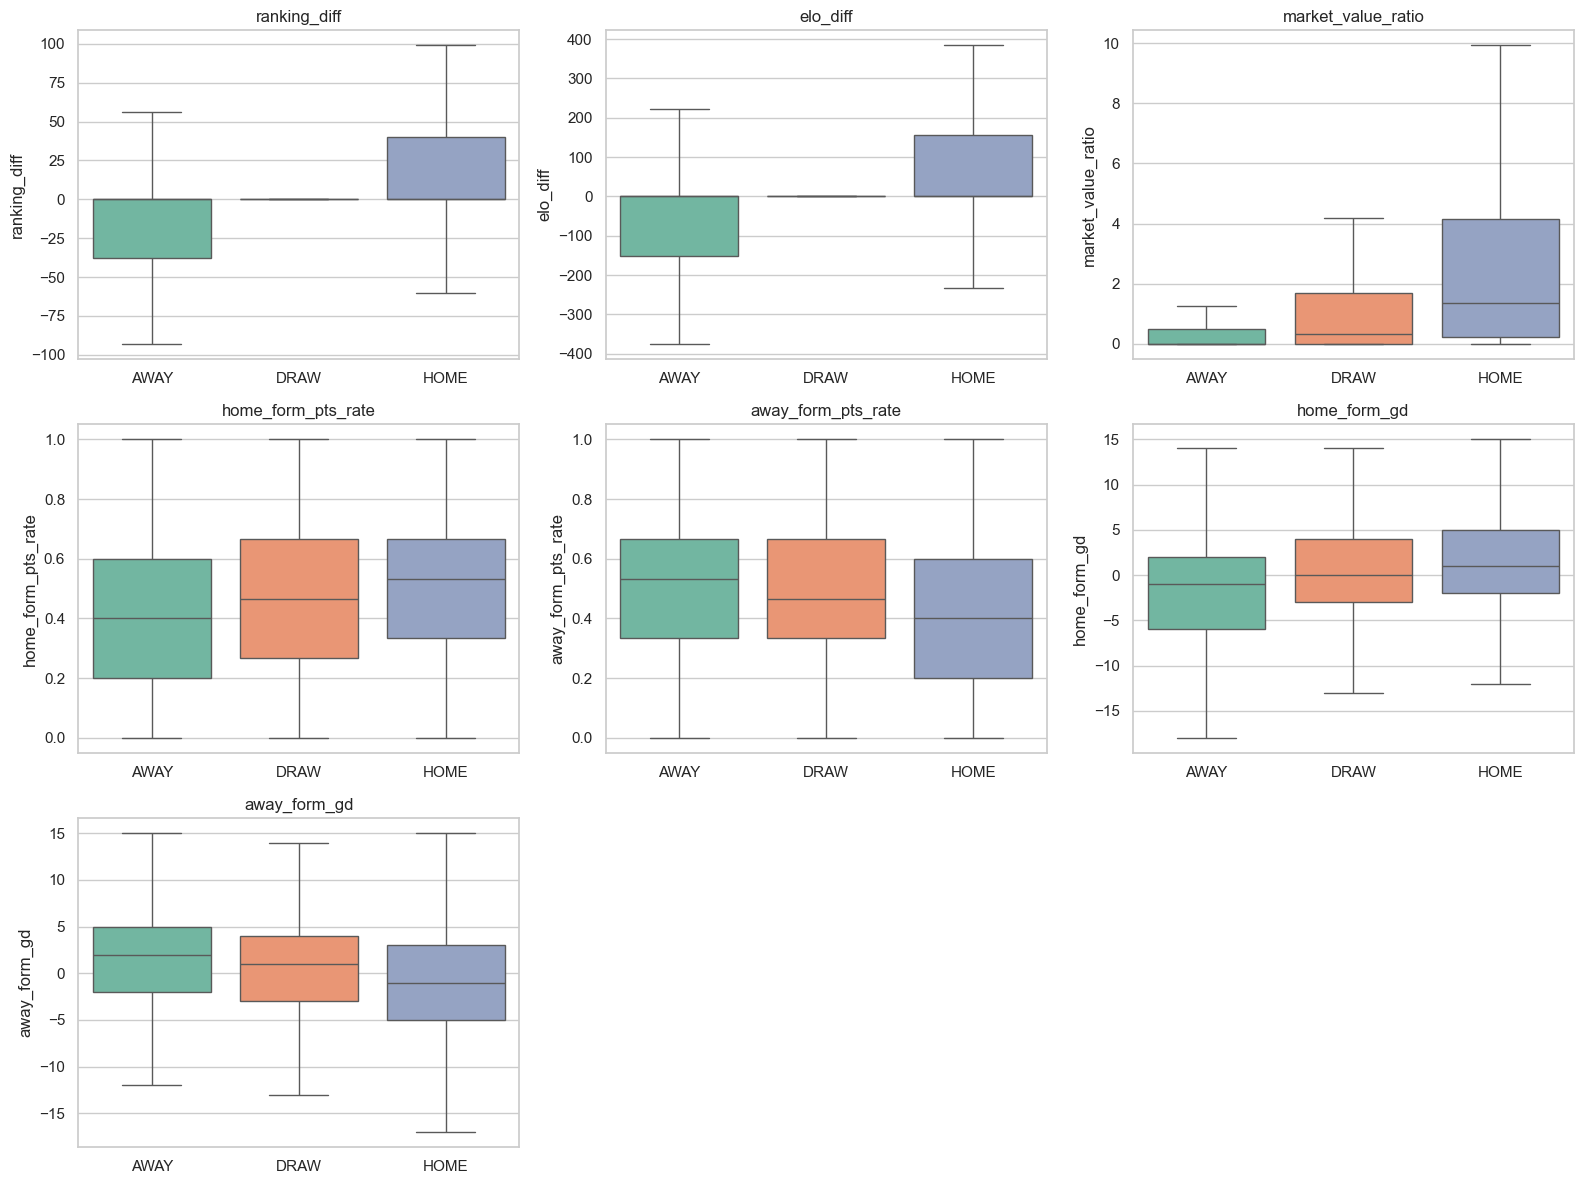

In [12]:
key_features = [
    "ranking_diff",
    "elo_diff",
    "market_value_ratio",
    "home_form_pts_rate",
    "away_form_pts_rate",
    "home_form_gd",
    "away_form_gd",
]
order = ["AWAY", "DRAW", "HOME"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, key_features):
    sns.boxplot(data=df, x="result", y=col, order=order, ax=ax, palette="Set2", showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("")
for ax in axes[len(key_features):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Effect of Categorical / Binary Variables (Neutral Ground, World Cup)

`neutral` and `is_world_cup` are not continuous, so boxplots are not appropriate: instead we look at the distribution of results conditioned on these variables.

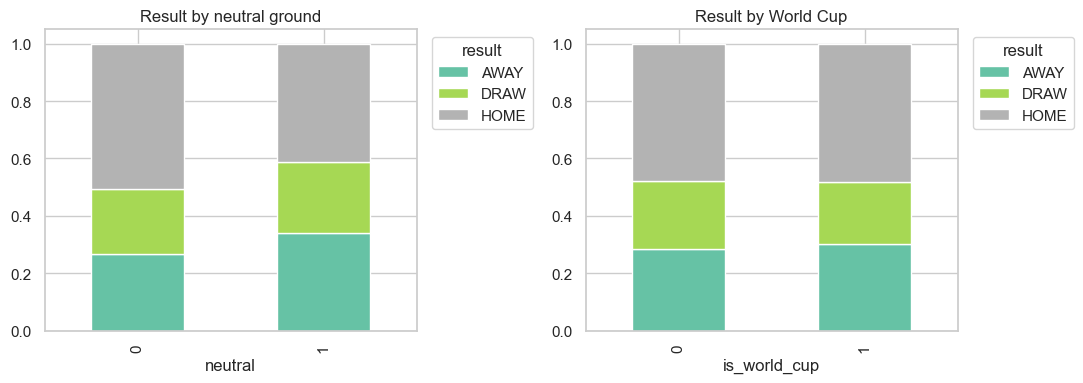

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

pd.crosstab(df["neutral"], df["result"], normalize="index")[order].plot(
    kind="bar", stacked=True, ax=axes[0], colormap="Set2"
)
axes[0].set_title("Result by neutral ground")
axes[0].set_xlabel("neutral")
axes[0].legend(title="result", bbox_to_anchor=(1.02, 1), loc="upper left")

pd.crosstab(df["is_world_cup"], df["result"], normalize="index")[order].plot(
    kind="bar", stacked=True, ax=axes[1], colormap="Set2"
)
axes[1].set_title("Result by World Cup")
axes[1].set_xlabel("is_world_cup")
axes[1].legend(title="result", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Summary for Feature Selection

Based on the analyses above, some directions for building the model feature set:

- **Most promising features (strong correlation with `result`, low redundancy)**: `elo_diff`, `ranking_diff`, `market_value_ratio`, form rates (`home_form_pts_rate`, `away_form_pts_rate`) and goal differentials (`home_form_gd`, `away_form_gd`).
- **Redundancy to resolve**: if `ranking_diff` and `elo_diff` are strongly correlated (see `strong_pairs`), keep only one (ELO is generally more continuous/informative than FIFA ranking). Similarly for `home_market_value`/`away_market_value` vs `market_value_ratio`: prefer the ratio which directly captures the gap.
- **Missing values**: features derived from rankings/ELO/market value only cover part of the matches (see NaN chart). To use them without losing too many rows, plan for imputation (median, or a dedicated model) rather than dropping them.
- **Useful contextual variables but weakly correlated alone**: `neutral`, `is_world_cup`, `home_days_rest`/`away_days_rest` can remain as they interact with other features (e.g. a favourite playing away on neutral ground) even if their marginal correlation with `result` is low.
- **Head-to-head history (`h2h_*`)**: relevant mainly when `h2h_matches` is large enough; on small samples (low h2h_matches), these features are noisy.
- **Exclude from the model as-is**: `date`, `home_team`, `away_team`, `tournament` are not directly usable (identifiers/text) — they can serve as a basis for derived features (team strength already captured by elo/ranking, tournament type) but cannot be fed raw into a classic model.